# **✅ Task 11: SVM – Breast Cancer Classification:**

## **Importing Required Modules:**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC,SVR
from sklearn.metrics import accuracy_score,roc_auc_score,confusion_matrix
from sklearn.metrics import classification_report,roc_curve,auc
from sklearn.model_selection import train_test_split,GridSearchCV

## **Load dataset and inspect features and labels distribution:**

In [ ]:
data = load_breast_cancer(as_frame=True)
df = data.frame

In [ ]:
df.to_csv("breast_cancer.csv",index=False)

In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.shape

(569, 31)

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
X = df.drop('target',axis=1)
y = df['target']

In [ ]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


## **Apply StandardScaler to normalize feature values:**

In [ ]:
scaler = StandardScaler()

In [ ]:
df_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(df_scaled, columns=X.columns)

In [ ]:
df_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


## **Split data into train-test sets:**

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(df_scaled,y,test_size=0.2,random_state=42,stratify=y)

## **Train baseline SVM with linear kernel and check performance:**

In [ ]:
clf = SVC(kernel='linear')

In [ ]:
clf.fit(X_train,y_train)

SVC(kernel='linear')

In [ ]:
y_pred_clf = clf.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_clf)

0.9736842105263158

## **Train SVM with RBF kernel and compare accuracy:**

In [ ]:
rbf = SVC(kernel='rbf')

In [ ]:
rbf.fit(X_train,y_train)

SVC()

In [ ]:
y_pred_rbf = rbf.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_rbf) # rbf kernel gives more accuracy than linear kernel

0.9824561403508771

## **Use GridSearchCV to tune C and gamma values:**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

In [ ]:
grid = GridSearchCV(
    SVC(kernel="rbf", probability=True),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 1]},
             scoring='accuracy')

In [ ]:
print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

Best Parameters: {'C': 10, 'gamma': 0.01}


In [ ]:
y_pred_best = best_model.predict(X_test)

## **Evaluate best model using confusion matrix and classification report:**

In [ ]:
confusion_matrix(y_test, y_pred_best)

array([[41,  1],
       [ 1, 71]])

In [ ]:
print("Classification Report:\n",classification_report(y_test, y_pred_best))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## **Plot ROC curve and calculate AUC score:**

In [ ]:
y_prob = best_model.predict_proba(X_test)[:,1]
y_prob

array([3.67611996e-05, 9.99999730e-01, 2.43364836e-02, 5.54313688e-01,
       2.01056955e-05, 9.75280462e-01, 9.99999735e-01, 2.76900741e-05,
       2.01159398e-04, 1.66106121e-04, 9.87970030e-01, 1.24044067e-03,
       9.95396989e-01, 2.40805643e-04, 1.46969826e-03, 8.80466800e-01,
       3.43880495e-01, 9.30076622e-01, 9.99997437e-01, 9.36643304e-01,
       1.60407821e-03, 7.84518261e-02, 9.99991561e-01, 8.96926830e-01,
       9.81438509e-01, 8.97220537e-01, 7.50417725e-06, 9.87623666e-01,
       9.99994499e-01, 9.95754773e-01, 9.74699475e-01, 9.99999913e-01,
       9.87438837e-01, 9.36568370e-01, 6.31480320e-05, 2.72619955e-01,
       9.93800519e-01, 9.32529369e-01, 5.28692017e-01, 6.19216256e-05,
       9.99998914e-01, 9.99998043e-01, 9.88200350e-01, 1.67573260e-04,
       5.53965296e-03, 7.65672374e-01, 9.99999827e-01, 9.99998241e-01,
       9.22787974e-01, 6.83375593e-04, 9.99989666e-01, 5.55180949e-01,
       9.99988653e-01, 8.73440557e-01, 9.34732890e-01, 9.99993412e-01,
      

In [ ]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)

In [ ]:
roc_auc = roc_auc_score(y_test,y_prob)
roc_auc

np.float64(0.998015873015873)

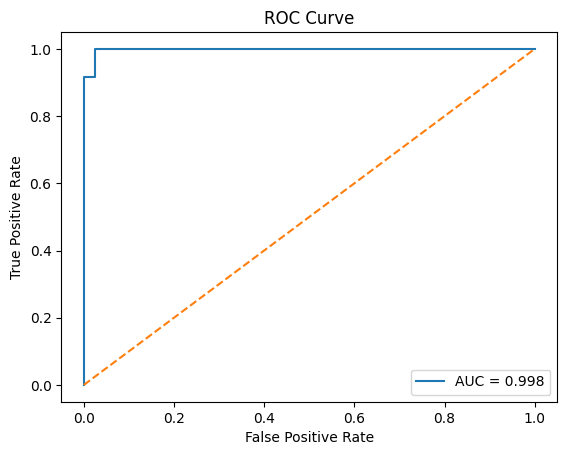

In [ ]:
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png")
plt.show()

## **Save tuned model pipeline (scaler + svm) for reuse:**

In [ ]:
from sklearn.pipeline import Pipeline
import joblib

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", best_model)
])

In [ ]:
pipeline.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=10, gamma=0.01, probability=True))])

In [ ]:
joblib.dump(pipeline, "svm_best_pipeline.pkl")
print("Model saved as svm_best_pipeline.pkl")

Model saved as svm_best_pipeline.pkl
